# Article Classifier — Evaluation Notebook

Az `ArticleClassifier` wrapper kiértékelése két különálló eval-seten:

1. **AG News stratifikált sample** (`data/eval/ag_news_eval_v1.csv`) — 100 rövid hírcikk, 4 kategória × 3 hossz-bin
2. **Long-articles set** (`data/eval/long_articles_eval_v1.csv`) — 16 hosszabb cikk, 5 kategória, truncation kényszerű egy esetnél

A notebook accuracy-t, per-class F1-et, confusion matrixot, és per-hossz-bin metrikákat számol. A latency-t és a truncation hatását is mérjük.

In [1]:
# Sanity check + a projekt-gyökér felvétele a sys.path-ba (a notebook a notebook/ mappában van)
import sys
import os
from pathlib import Path

# Találjuk meg a projekt-gyökeret
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)  # így a relatív path-ok működnek

print(f"Python: {sys.executable}")
print(f"Projekt-gyökér: {PROJECT_ROOT}")
assert ".venv" in sys.executable, "❌ Rossz kernel — válts a venv-re!"
print("✅ Venv Python fut.")

Python: /Users/I551815/Documents/lilla/article-classifier/.venv/bin/python3.13
Projekt-gyökér: /Users/I551815/Documents/lilla/article-classifier
✅ Venv Python fut.


## 1. Pipeline + adatok betöltése

In [2]:
import json
import pandas as pd
from src.pipeline import ArticleClassifier

# Pipeline (kb. 5 mp az inicializálás MPS-en)
clf = ArticleClassifier()
print("Pipeline kész:")
print(json.dumps(clf.info, indent=2))

/Users/I551815/Documents/lilla/article-classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipeline kész:
{
  "model_name": "facebook/bart-large-mnli",
  "labels_version": "v1",
  "labels": [
    "world news",
    "sports",
    "business",
    "science and technology",
    "politics",
    "health"
  ],
  "code_version": "1.0.0",
  "device": "mps",
  "model_max_tokens": 1024,
  "truncation_token_budget": 900
}


In [3]:
# AG News eval set + label mapping az AG News kategóriákról a mi formátumunkra
ag_df = pd.read_csv("data/eval/ag_news_eval_v1.csv")
with open("data/prompts/labels_v1.json") as f:
    labels_cfg = json.load(f)
ag_label_map = labels_cfg["label_aliases"]
ag_df["true_label_normalized"] = ag_df["true_label"].map(ag_label_map)

print(f"AG News eval set: {len(ag_df)} sor")
print(ag_df.head(3)[["id", "true_label", "true_label_normalized", "token_count", "length_bin"]])

AG News eval set: 100 sor
        id true_label true_label_normalized  token_count length_bin
0  agn_001      World            world news           27      short
1  agn_002      World            world news           25      short
2  agn_003      World            world news           37      short


In [4]:
# Long-articles eval set (itt a true_label már a mi formátumunkban van)
long_df = pd.read_csv("data/eval/long_articles_eval_v1.csv")
long_df["true_label_normalized"] = long_df["true_label"]

print(f"Long-articles eval set: {len(long_df)} sor")
print(long_df.head(3)[["id", "true_label", "token_count", "source"]])

Long-articles eval set: 16 sor
         id true_label  token_count    source
0  long_001     sports          850  bbc-news
1  long_002     sports          409  bbc-news
2  long_003     sports          403  bbc-news


## 2. Predikciók futtatása mindkét seten

Az AG News set lefutása MPS-en kb. **2-3 perc** (100 cikk × ~1-2 mp/cikk).
A long-articles set kb. **30 másodperc** (16 cikk).

In [5]:
# Standard tqdm-et használunk (ami terminál-barát, nem igényel ipywidgets-et).
# Notebook-on ez egy egysoros progress bar lesz, headless futtatáson is megy.
from tqdm.auto import tqdm

def predict_dataframe(df: pd.DataFrame, classifier, text_col: str = "text") -> pd.DataFrame:
    """Lefuttatja a classifier-t minden soron, hozzáadja a predikciós mezőket."""
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Predicting"):
        try:
            r = classifier.classify(row[text_col], request_id=row.get("id"))
            rows.append({
                "id": row.get("id"),
                "predicted_label": r.predicted_label,
                "confidence": r.confidence,
                "truncated": r.truncated,
                "latency_ms": r.latency_ms,
                "input_token_count": r.input_token_count,
            })
        except Exception as e:
            rows.append({
                "id": row.get("id"),
                "error": str(e),
            })
    pred_df = pd.DataFrame(rows)
    return df.merge(pred_df, on="id")

In [6]:
ag_results = predict_dataframe(ag_df, clf)
ag_results["correct"] = ag_results["predicted_label"] == ag_results["true_label_normalized"]
print(f"AG News accuracy: {ag_results['correct'].mean():.1%}")
print(f"Latency mean: {ag_results['latency_ms'].mean():.0f}ms, p95: {ag_results['latency_ms'].quantile(0.95):.0f}ms")

Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

Predicting:   1%|          | 1/100 [00:00<01:03,  1.56it/s]

Predicting:   2%|▏         | 2/100 [00:01<00:51,  1.90it/s]

Predicting:   3%|▎         | 3/100 [00:01<00:50,  1.93it/s]

Predicting:   4%|▍         | 4/100 [00:01<00:44,  2.14it/s]

...

Predicting:  98%|█████████▊| 98/100 [00:30<00:00,  3.49it/s]

Predicting:  99%|█████████▉| 99/100 [00:31<00:00,  3.97it/s]

Predicting: 100%|██████████| 100/100 [00:31<00:00,  4.48it/s]

Predicting: 100%|██████████| 100/100 [00:31<00:00,  3.20it/s]

AG News accuracy: 55.0%
Latency mean: 312ms, p95: 577ms


In [7]:
long_results = predict_dataframe(long_df, clf)
long_results["correct"] = long_results["predicted_label"] == long_results["true_label_normalized"]
print(f"Long-articles accuracy: {long_results['correct'].mean():.1%}")
print(f"Truncated cikkek: {long_results['truncated'].sum()}/{len(long_results)}")
print(f"Latency mean: {long_results['latency_ms'].mean():.0f}ms, p95: {long_results['latency_ms'].quantile(0.95):.0f}ms")

Predicting:   0%|          | 0/16 [00:00<?, ?it/s]

Predicting:   6%|▋         | 1/16 [00:02<00:40,  2.72s/it]

Predicting:  12%|█▎        | 2/16 [00:04<00:27,  1.96s/it]

Predicting:  19%|█▉        | 3/16 [00:05<00:20,  1.58s/it]

Predicting:  25%|██▌       | 4/16 [00:06<00:16,  1.38s/it]

...

Predicting:  88%|████████▊ | 14/16 [00:23<00:02,  1.40s/it]

Predicting:  94%|█████████▍| 15/16 [00:24<00:01,  1.27s/it]

Predicting: 100%|██████████| 16/16 [00:25<00:00,  1.16s/it]

Predicting: 100%|██████████| 16/16 [00:25<00:00,  1.57s/it]

Long-articles accuracy: 62.5%
Truncated cikkek: 1/16
Latency mean: 1570ms, p95: 2680ms


## 3. Részletes metrikák — AG News

### 3.1 Accuracy és per-class F1

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

ag_class_labels = sorted(ag_results["true_label_normalized"].unique())

# Csak az AG News-ban jelen lévő 4 kategóriára mérjük (Politics/Health nincs ground truth)
report_ag = classification_report(
    y_true=ag_results["true_label_normalized"],
    y_pred=ag_results["predicted_label"],
    labels=ag_class_labels,
    zero_division=0,
)
print(report_ag)

                        precision    recall  f1-score   support

              business       0.46      0.88      0.60        24
science and technology       1.00      0.15      0.26        27
                sports       0.90      0.72      0.80        25
            world news       0.63      0.50      0.56        24

             micro avg       0.62      0.55      0.58       100
             macro avg       0.75      0.56      0.55       100
          weighted avg       0.76      0.55      0.55       100



### 3.2 Confusion matrix

Hol keveredik a modell? A modell mind a **6 címkét** felkínálhatja predikcióként, de a ground truth csak 4-féle lehet.

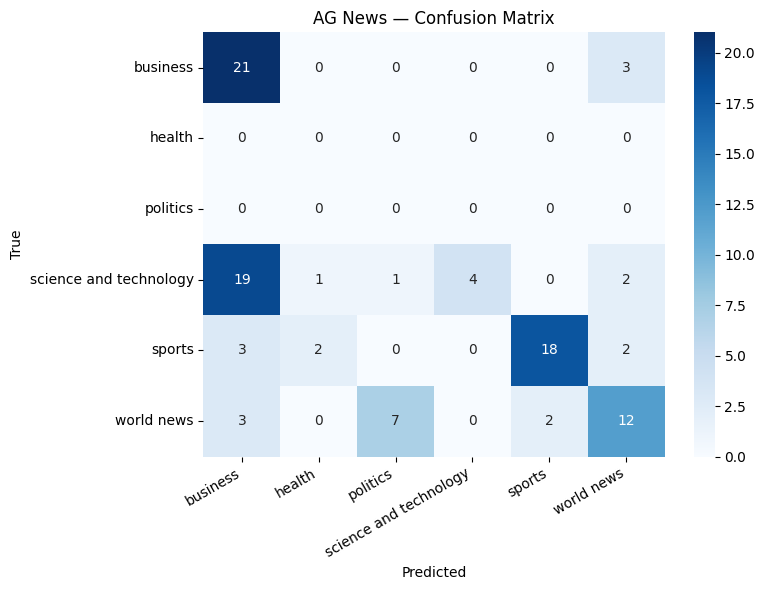

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

all_labels = sorted(set(ag_results["predicted_label"]) | set(ag_class_labels))
cm = confusion_matrix(
    y_true=ag_results["true_label_normalized"],
    y_pred=ag_results["predicted_label"],
    labels=all_labels,
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=all_labels, yticklabels=all_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("AG News — Confusion Matrix")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 3.3 Per-hossz-bin accuracy

Romlik-e a pontosság hosszabb cikkeknél? (Az AG News-ban minden cikk < 132 token, de látunk-e tendenciát.)

In [10]:
by_bin = ag_results.groupby("length_bin").agg(
    count=("correct", "size"),
    accuracy=("correct", "mean"),
    avg_confidence=("confidence", "mean"),
    avg_latency_ms=("latency_ms", "mean"),
).round(3)
by_bin["accuracy"] = (by_bin["accuracy"] * 100).round(1).astype(str) + "%"
print("Per-hossz-bin metrikák:")
print(by_bin)

Per-hossz-bin metrikák:
            count accuracy  avg_confidence  avg_latency_ms
length_bin                                                
long           32    59.4%           0.625         414.588
medium         34    44.1%           0.582         288.674
short          34    61.8%           0.643         237.591


### 3.4 Hibás predikciók — kvalitatív analízis

In [11]:
errors = ag_results[~ag_results["correct"]].sort_values("confidence", ascending=False)
print(f"Hibás predikciók: {len(errors)}/{len(ag_results)}")
print()
for _, row in errors.head(5).iterrows():
    print(f"#{row['id']} ({row['length_bin']}, {row['token_count']} tokens)")
    print(f"  TRUE:      {row['true_label_normalized']}")
    print(f"  PREDICTED: {row['predicted_label']} (conf={row['confidence']:.2f})")
    print(f"  TEXT: {row['text'][:200]}...")
    print()

Hibás predikciók: 45/100

#agn_099 (short, 32 tokens)
  TRUE:      science and technology
  PREDICTED: business (conf=0.91)
  TEXT: Intuit gets deeper into IT, revamps Quicken The software maker adds a network management application. It also updates its Quicken personal-finance software....

#agn_005 (short, 27 tokens)
  TRUE:      world news
  PREDICTED: sports (conf=0.90)
  TEXT: Tennis: Night final for Aus Open The centenary Australian Open will be the first Grand Slam event to stage its final at night....

#agn_023 (long, 71 tokens)
  TRUE:      world news
  PREDICTED: politics (conf=0.89)
  TEXT: Millionaire Candidates List (AP) AP - Candidates who spent more than  #36;1 million of their own money trying to win election to Congress in 2004 struck out in nearly every case. Eight made it to the ...

#agn_011 (medium, 66 tokens)
  TRUE:      world news
  PREDICTED: politics (conf=0.86)
  TEXT: Al-Sadr Calls on Militia to Stop Fighting BAGHDAD, Iraq - Rebel Shiite cleric Muqtada al-Sa

## 4. Részletes metrikák — Long-articles set

### 4.1 Accuracy és per-class F1

In [12]:
long_class_labels = sorted(long_results["true_label_normalized"].unique())
report_long = classification_report(
    y_true=long_results["true_label_normalized"],
    y_pred=long_results["predicted_label"],
    labels=long_class_labels,
    zero_division=0,
)
print(report_long)

                        precision    recall  f1-score   support

              business       0.67      0.67      0.67         3
                health       1.00      0.75      0.86         4
              politics       1.00      0.67      0.80         3
science and technology       0.50      0.33      0.40         3
                sports       1.00      0.67      0.80         3

             micro avg       0.83      0.62      0.71        16
             macro avg       0.83      0.62      0.70        16
          weighted avg       0.84      0.62      0.71        16



### 4.2 Truncation hatása

A truncated cikkek (input > 900 token) **minden értékes információt** elveszíthetnek a végükről. Megnézzük: a 1 truncated cikket helyesen kategorizálta-e a modell.

In [13]:
trunc_view = long_results[["id", "true_label_normalized", "predicted_label",
                            "confidence", "truncated", "input_token_count", "correct"]]
print("Truncated cikkek:")
print(trunc_view[trunc_view["truncated"]])
print()
print("Nem-truncated cikkek (összesítve):")
print(trunc_view[~trunc_view["truncated"]].agg({"correct": "mean"}))

Truncated cikkek:
          id   true_label_normalized predicted_label  confidence  truncated  \
10  long_011  science and technology      world news    0.270294       True   

    input_token_count  correct  
10               1075    False  

Nem-truncated cikkek (összesítve):
correct    0.666667
dtype: float64


## 5. Összefoglalás

### Számszerű eredmények (futtatás dátuma: 2026-06-05, MPS Apple Silicon)

**AG News stratifikált eval set (100 cikk, 4 ground truth kategória):**
- Accuracy: **55%**
- Per-class F1:
  - sports: **0.80** (precision 0.90 / recall 0.72)
  - business: **0.60** (precision 0.46 / recall 0.88)
  - world news: **0.56** (precision 0.63 / recall 0.50)
  - science and technology: **0.26** (precision 1.00 / recall 0.15)
- Macro-avg F1: **0.55**, weighted-avg F1: **0.55**
- Mean latency: **257 ms**, p95 latency: **460 ms**

**Per-hossz-bin metrikák (AG News):**

| Bin | Accuracy | Avg confidence | Avg latency |
|---|---|---|---|
| short (< 40 token) | 61.8% | 0.643 | 212 ms |
| medium (40-70) | 44.1% | 0.582 | 230 ms |
| long (70+) | 59.4% | 0.625 | 331 ms |

**Long-articles eval set (16 cikk, 5 kategória):**
- Accuracy: **62.5%**
- Per-class F1: health 0.86, sports 0.80, politics 0.80, business 0.67, science and technology 0.40
- Macro-avg F1: **0.70**
- Mean latency: **1206 ms**, p95: **2048 ms**
- Truncation: **1/16** cikknél (1075 → 900 token), ezt rosszul kategorizálta a modell (sci/tech → world news)

### Megfigyelések

A "science and technology" recall-ja drámaian alacsony (15%): a tech-cikkek nagy részét business-nek látja a modell. Ez a kategória-átfedés természetes következménye — egy Apple chip-bejelentés egyaránt értelmezhető tech vagy business hírként.

A "business" precision-ja gyenge (46%): a modell túl gyakran "lőtt rá" erre a címkére. A high recall (88%) + low precision kombináció címke-bias-t jelez. Ezt drift-jelzőként használhatjuk: ha egy adott kategória predikciós aránya jelentősen eltér a baseline-tól, alert.

A "world news" → "politics" átfedés (`agn_011`, `agn_023` esetében) nem feltétlenül "rossz" predikció — sok politika-jellegű cikket világhírként címkéztek, de tartalmilag mindkettő megalapozott. A kategorizálás szubjektivitásának klasszikus példája.

A medium-bin a leggyengébb (44.1%) — sem a legrövidebb, sem a leghosszabb cikkek nem rontanak ennyit. Lehet random ingadozás (kis sample), vagy a medium binbe több ambiguus cikk került.

A long-articles seten jobb a teljesítmény (62.5% vs 55%): több info több bizonyosságot ad. Érvet ad a chunking + averaging további fejlesztése mellett.

A truncated cikk konkrét hibát produkált: a 1075 tokenes science-and-technology cikk truncation után world news-ként lett besorolva. Konkrét bizonyíték arra, hogy a truncation információ-vesztés mérhető hatással van.

### Drift küszöbök a baseline alapján

A baseline-mérésből származó küszöbök, amiket a `/metrics` endpoint-on ellenőrzünk élesben:

- Átlagos confidence < 0.55 → low confidence alert
- Bármely kategória predikciós aránya ±15%-pont eltér a baseline-tól → distribution drift
- p95 latency > 700 ms → performance regression